In [80]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [81]:
import pandas as pd
import numpy as np

In [82]:
X_train = np.linspace(-1,1,20)

In [83]:
X_test = np.linspace(-1,1,20)

In [84]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  , 
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475, 
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,  
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [85]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,  
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

In [86]:
import matplotlib.pyplot as plt

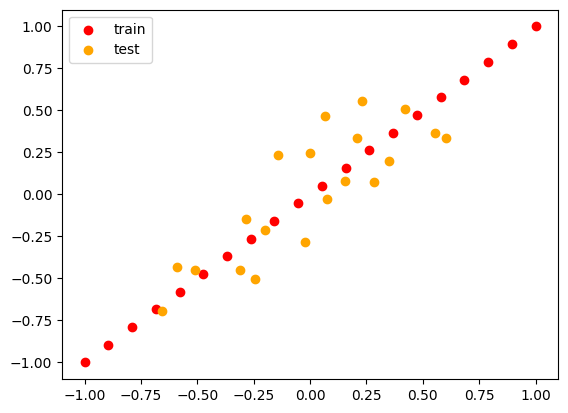

In [87]:
plt.scatter(X_train,X_test,label = 'train',c = 'red')
plt.scatter(y_train,y_test,label = 'test',c = 'orange')
plt.legend()
plt.show()

In [88]:
model = Sequential()

model.add(Dense(128,activation = 'relu',input_dim = 1))
model.add(Dense(128,activation = 'sigmoid'))
model.add(Dense(1,activation = 'linear'))


In [89]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
adam = Adam(learning_rate = 0.01)
model.compile(loss = 'mse',optimizer = adam,metrics = ['mse'])

In [91]:
X_train.shape

(20,)

In [92]:
X_test.shape

(20,)

In [93]:
y_train.shape

(20,)

In [94]:
y_test.shape

(20,)

In [95]:
history = model.fit(X_train,y_train,validation_data = (X_test,y_test),epochs = 500)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - loss: 0.1606 - mse: 0.1606 - val_loss: 0.3147 - val_mse: 0.3147
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2932 - mse: 0.2932 - val_loss: 0.0513 - val_mse: 0.0513
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0356 - mse: 0.0356 - val_loss: 0.1274 - val_mse: 0.1274
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1184 - mse: 0.1184 - val_loss: 0.1531 - val_mse: 0.1531
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1451 - mse: 0.1451 - val_loss: 0.0530 - val_mse: 0.0530
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0425 - mse: 0.0425 - val_loss: 0.0542 - val_mse: 0.0542
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0407 - mse: 0.0407 - val_loss: 0.1097 - val_mse: 0.1097
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0945 - mse: 0.0945 - val_loss: 0.0892 - val_mse: 0.0892
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0744 - mse:

In [96]:
# evaluate the model
_, train_mse = model.evaluate(X_train, y_train, verbose=0)
_, test_mse = model.evaluate(X_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.010022643953561783, Test: 0.04157591611146927


In [97]:
y_pred_1 = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


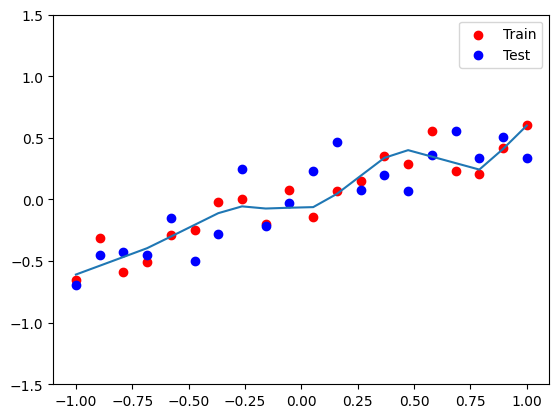

In [98]:
plt.figure()
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.plot(X_test, y_pred_1)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

In [120]:
model_1 = Sequential()


model_1.add(Dense(128,activation = 'relu',input_dim = 1))
model_1.add(Dropout(0.2))
model_1.add(Dense(128,activation = 'relu'))
model_1.add(Dropout(0.2))
model_1.add(Dense(1,activation = 'linear'))



In [122]:
adam = Adam(learning_rate = 0.01)
model_1.compile(loss = 'mse',optimizer = adam,metrics = ['mse'])

In [124]:
history_1 = model_1.fit(X_train,y_train,validation_data = (X_test,y_test),epochs = 500)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - loss: 0.1401 - mse: 0.1401 - val_loss: 0.0365 - val_mse: 0.0365
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0341 - mse: 0.0341 - val_loss: 0.0555 - val_mse: 0.0555
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0381 - mse: 0.0381 - val_loss: 0.0434 - val_mse: 0.0434
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0367 - mse: 0.0367 - val_loss: 0.0329 - val_mse: 0.0329
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0183 - mse: 0.0183 - val_loss: 0.0364 - val_mse: 0.0364
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0306 - mse: 0.0306 - val_loss: 0.0396 - val_mse: 0.0396
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0322 - mse: 0.0322 - val_loss: 0.0449 - val_mse: 0.0449
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0324 - mse: 0.0324 - val_loss: 0.0408 - val_mse: 0.0408
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0408 - mse:

In [126]:
_,train_mse = model_1.evaluate(X_train,y_train,verbose = 0)
_,test_mse = model_1.evaluate(X_test,y_test,verbose = 0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.009934632107615471, Test: 0.04052574187517166


In [128]:
y_pred_2 = model_1.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


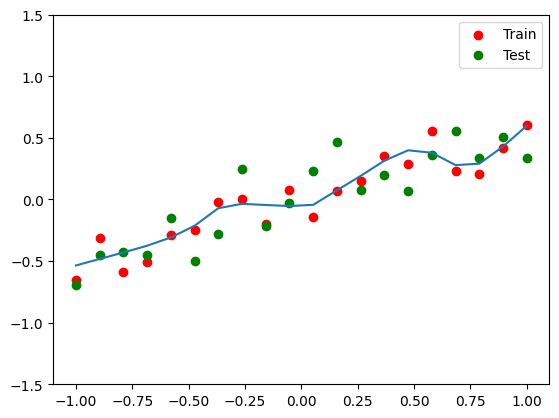

In [130]:
plt.figure()
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='green', label='Test')
plt.plot(X_test, y_pred_2)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

In [132]:
#dropout layer with 50perecnt neurons dropped

In [134]:
model_2 = Sequential()


model_2.add(Dense(128,activation = 'relu',input_dim = 1))
model_2.add(Dropout(0.5))
model_2.add(Dense(128,activation = 'relu'))
model_2.add(Dropout(0.5))
model_2.add(Dense(1,activation = 'linear'))


In [138]:
adam = Adam(learning_rate = 0.01)
model_2.compile(loss = 'mse',optimizer = adam,metrics = ['mse'])

In [140]:
history_3 = model_2.fit(X_train,y_train,validation_data = (X_test,y_test),epochs = 500)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - loss: 0.1516 - mse: 0.1516 - val_loss: 0.0339 - val_mse: 0.0339
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0584 - mse: 0.0584 - val_loss: 0.0475 - val_mse: 0.0475
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0425 - mse: 0.0425 - val_loss: 0.0456 - val_mse: 0.0456
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0759 - mse: 0.0759 - val_loss: 0.0303 - val_mse: 0.0303
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0438 - mse: 0.0438 - val_loss: 0.0307 - val_mse: 0.0307
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0281 - mse: 0.0281 - val_loss: 0.0401 - val_mse: 0.0401
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0331 - mse: 0.0331 - val_loss: 0.0465 - val_mse: 0.0465
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0381 - mse: 0.0381 - val_loss: 0.0516 - val_mse: 0.0516
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0516 - mse:

In [142]:
_,train_mse = model_2.evaluate(X_train,y_train,verbose = 0)
_,test_mse = model_2.evaluate(X_test,y_test,verbose = 0)
print("Train : {},Test : {}".format(train_mse,test_mse))

Train : 0.015391048975288868,Test : 0.0376984067261219


In [144]:
y_pred_3 = model_2.predict(X_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


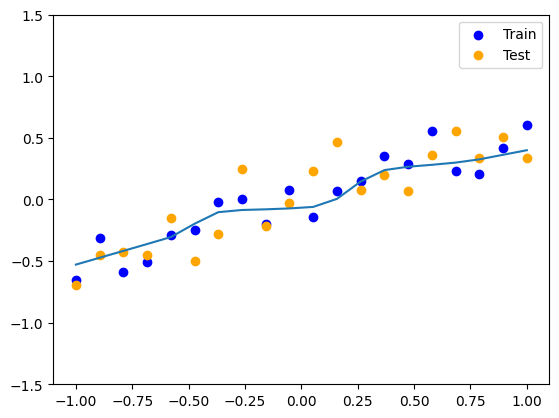

In [148]:
plt.figure()
plt.scatter(X_train,y_train,c = 'blue',label = 'Train')
plt.scatter(X_test,y_test,c = 'orange',label = 'Test')
plt.plot(X_test,y_pred_3)
plt.legend()
plt.ylim((-1.5,1.5))
plt.show()

In [152]:
from mlxtend.plotting import plot_decision_regions

In [156]:
y_test_int = y_test.astype(np.int_)